In [2]:
import statsmodels.api as sm

In [3]:
x = [0.010, -0.005, 0.009, 0.002, -0.008]   # 大盘日收益率
y = [0.012, -0.003, 0.010, 0.001, -0.006]   # AAPL日收益率

In [4]:
x = sm.add_constant(x)
model=sm.OLS(y,x)
result=model.fit()

In [5]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     112.5
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00179
Time:                        15:08:17   Log-Likelihood:                 26.782
No. Observations:                   5   AIC:                            -49.56
Df Residuals:                       3   BIC:                            -50.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.856      0.1

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


In [6]:
import pandas as pd
import sqlite3

In [7]:
conn=sqlite3.connect('stock_data.db')
aapl=pd.read_sql("select Date,Close from AAPL",conn)
msft=pd.read_sql("select Date,Close from MSFT",conn)

In [8]:
aapl['return']=aapl['Close'].pct_change()
msft['return']=msft['Close'].pct_change()

In [9]:
merged=pd.merge(aapl[['Date','return']],msft[['Date','return']],on='Date',suffixes=('_aapl', '_msft'))
merged=merged.dropna()
print(merged)

                    Date  return_aapl  return_msft
1    2025-01-03 00:00:00    -0.002009     0.011396
2    2025-01-06 00:00:00     0.006739     0.010630
3    2025-01-07 00:00:00    -0.011388    -0.012808
4    2025-01-08 00:00:00     0.002023     0.005185
5    2025-01-10 00:00:00    -0.024104    -0.013214
..                   ...          ...          ...
245  2025-12-24 00:00:00     0.005324     0.002403
246  2025-12-26 00:00:00    -0.001497    -0.000635
247  2025-12-29 00:00:00     0.001317    -0.001251
248  2025-12-30 00:00:00    -0.002484     0.000780
249  2025-12-31 00:00:00    -0.004468    -0.007918

[249 rows x 3 columns]


In [10]:
import statsmodels.api as sm
x = merged['return_msft']
y = merged['return_aapl']

In [11]:
x=sm.add_constant(x)
model=sm.OLS(y,x)
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            return_aapl   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     76.47
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.52e-16
Time:                        15:08:17   Log-Likelihood:                 649.31
No. Observations:                 249   AIC:                            -1295.
Df Residuals:                     247   BIC:                            -1288.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0002      0.001      0.167      

In [12]:
import yfinance as yf
import pandas as pd
def get_stock_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    data.columns = data.columns.get_level_values(0)
    return data

In [13]:
name = pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table'", conn)
print(name)

        name
0       AAPL
1       MSFT
2  600519_SS
3  000001_SZ
4       GSPC


In [14]:
gspc=pd.read_sql("select Date,Close from GSPC",conn)
gspc['return'] = gspc['Close'].pct_change()
aapl=pd.read_sql("select Date,Close from AAPL",conn)
aapl['return'] = aapl['Close'].pct_change()

In [15]:
merged=pd.merge(gspc[['Date','return']],aapl[['Date','return']],on='Date',suffixes=['_gspc','_aapl'])
merged=merged.dropna()
print(merged)

                    Date  return_gspc  return_aapl
1    2025-01-03 00:00:00     0.012596    -0.002009
2    2025-01-06 00:00:00     0.005538     0.006739
3    2025-01-07 00:00:00    -0.011104    -0.011388
4    2025-01-08 00:00:00     0.001560     0.002023
5    2025-01-10 00:00:00    -0.015412    -0.024104
..                   ...          ...          ...
245  2025-12-24 00:00:00     0.003221     0.005324
246  2025-12-26 00:00:00    -0.000304    -0.001497
247  2025-12-29 00:00:00    -0.003492     0.001317
248  2025-12-30 00:00:00    -0.001376    -0.002484
249  2025-12-31 00:00:00    -0.007358    -0.004468

[249 rows x 3 columns]


In [16]:
x =  merged['return_gspc']
y =  merged['return_aapl']
x = sm.add_constant(x)
model=sm.OLS(y,x)
result = model.fit()


In [17]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:            return_aapl   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     320.0
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.80e-46
Time:                        15:08:18   Log-Likelihood:                 719.20
No. Observations:                 249   AIC:                            -1434.
Df Residuals:                     247   BIC:                            -1427.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0002      0.001     -0.271      

In [18]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac系统常见的中文字体
plt.rcParams['axes.unicode_minus'] = False  # 防止负号也显示异常

In [19]:
fitted = result.fittedvalues
actual = merged['return_aapl']

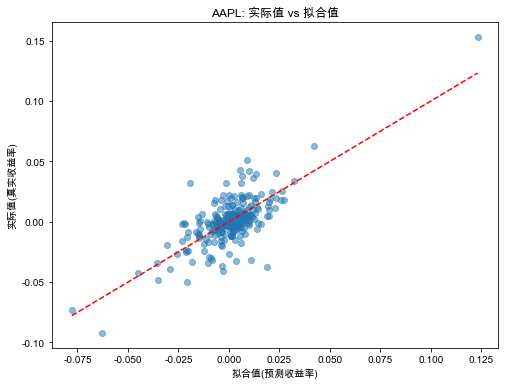

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(fitted, actual, alpha=0.5)
ax.plot([fitted.min(), fitted.max()], [fitted.min(), fitted.max()], color='red', linestyle='--')
ax.set_xlabel('拟合值(预测收益率)')
ax.set_ylabel('实际值(真实收益率)')
ax.set_title('AAPL: 实际值 vs 拟合值')
fig.savefig('AAPL实际值与拟合值.png',dpi=300)
plt.show()

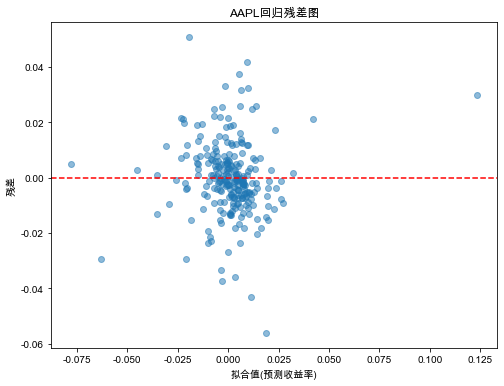

In [21]:
residuals = result.resid   # resid = residuals的缩写，取出残差
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(fitted, residuals, alpha=0.5)
ax.axhline(y=0, color='red', linestyle='--')  # 画一条y=0的参考线
ax.set_xlabel('拟合值(预测收益率)')
ax.set_ylabel('残差')
ax.set_title('AAPL回归残差图')
plt.show()